In [ ]:
import pickle
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns

# Базовые модели
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Ансамблевые модели
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, VotingClassifier, IsolationForest
from sklearn.ensemble import StackingClassifier

# Загрузка данных
with open('train_dataset_normalized.pkl', 'rb') as f:
    data = pickle.load(f)

df = pd.DataFrame(data)

df.to_csv("train_data.csv")



In [ ]:
print("Размер данных:", df.shape)
df.head(10)

Размер данных: (548, 19)


,Прогрессия,Число очагов,Объем очагов,Число РХ процедур,Индекс Карновского,ОВГМ,Операция,Возраст,Время метастазирования,Время реагирования,КРР,Меланома,НМРЛ,РМЖ,РП,Таргетная терапия,Химиотерапия,Без лечения,Мужчина
0,1,0.095238,0.008543,0.0,0.666667,0,0,0.490909,0.076249,0.165963,0,1,0,0,0,0,1,0,1
1,1,0.095238,0.101619,0.0,0.666667,0,0,0.690909,0.034228,-0.004219,0,0,0,0,1,0,0,0,1
2,0,0.476190,0.178732,0.0,0.666667,0,0,0.454545,0.203423,0.018284,1,0,0,0,0,0,1,0,0
3,1,0.285714,0.062950,0.2,0.666667,0,0,0.472727,0.068179,0.030942,0,0,0,1,0,1,0,0,0
4,1,0.476190,0.127023,0.8,0.666667,0,0,0.472727,0.012801,0.014065,0,0,0,0,1,1,0,0,0
5,1,0.190476,0.085432,0.2,0.666667,1,0,0.454545,0.584667,0.811533,0,0,0,1,0,1,0,0,0
6,0,0.190476,0.225944,0.0,0.833333,0,0,0.454545,0.122861,0.018284,0,0,0,0,1,0,0,0,1
7,0,0.047619,0.146583,0.0,0.666667,0,1,0.781818,0.072353,0.345992,1,0,0,0,0,0,0,0,1
8,1,0.000000,0.180306,0.2,0.833333,1,0,0.672727,0.110338,0.018284,0,1,0,0,0,0,1,0,0
9,1,0.047619,0.273831,0.4,0.666667,0,0,0.563636,0.512592,0.081575,0,0,0,1,0,0,1,0,0


In [ ]:
X = df.iloc[:, ~df.columns.isin(['Прогрессия'])]
y = df['Прогрессия']

print("Информация о данных:")
print(f"Признаки: {X.shape}")
print(f"Целевая переменная: {y.shape}")
print(f"Классы: {np.unique(y)}")
display(X)
y

Информация о данных:
Признаки: (548, 18)
Целевая переменная: (548,)
Классы: [0 1]


,Число очагов,Объем очагов,Число РХ процедур,Индекс Карновского,ОВГМ,Операция,Возраст,Время метастазирования,Время реагирования,КРР,Меланома,НМРЛ,РМЖ,РП,Таргетная терапия,Химиотерапия,Без лечения,Мужчина
0,0.095238,0.008543,0.0,0.666667,0,0,0.490909,0.076249,0.165963,0,1,0,0,0,0,1,0,1
1,0.095238,0.101619,0.0,0.666667,0,0,0.690909,0.034228,-0.004219,0,0,0,0,1,0,0,0,1
2,0.476190,0.178732,0.0,0.666667,0,0,0.454545,0.203423,0.018284,1,0,0,0,0,0,1,0,0
3,0.285714,0.062950,0.2,0.666667,0,0,0.472727,0.068179,0.030942,0,0,0,1,0,1,0,0,0
4,0.476190,0.127023,0.8,0.666667,0,0,0.472727,0.012801,0.014065,0,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543,0.000000,0.268885,0.0,0.500000,0,0,0.618182,0.093363,0.032349,1,0,0,0,0,0,1,0,1
544,0.857143,0.044739,0.4,0.666667,1,0,0.181818,0.115208,-0.015471,0,1,0,0,0,1,0,0,0
545,0.523810,0.214478,0.0,0.500000,0,0,0.072727,0.016836,0.028129,0,1,0,0,0,0,0,0,1
546,0.142857,0.054406,0.0,0.500000,0,0,0.545455,0.080840,0.042194,0,0,0,0,1,1,0,0,0


,Прогрессия
0,1
1,1
2,0
3,1
4,1
...,...
543,0
544,1
545,0
546,0


# Распределение данных на обучение и проверку

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Разделение данных:")
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Разделение данных:
Обучающая выборка: (438, 18)
Тестовая выборка: (110, 18)


# Подготовка данных для обучения и тестирования

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

display(X_test)
X_train_scaled

,Число очагов,Объем очагов,Число РХ процедур,Индекс Карновского,ОВГМ,Операция,Возраст,Время метастазирования,Время реагирования,КРР,Меланома,НМРЛ,РМЖ,РП,Таргетная терапия,Химиотерапия,Без лечения,Мужчина
253,0.142857,0.139838,0.4,0.666667,0,1,0.727273,0.050925,0.386779,0,0,1,0,0,1,0,0,1
306,0.142857,0.309128,0.2,0.666667,0,1,0.600000,0.055239,0.296765,1,0,0,0,0,0,1,0,0
428,0.095238,0.113759,0.0,0.500000,0,0,0.745455,0.066787,0.015471,0,0,1,0,0,1,0,0,1
538,0.047619,0.194694,0.0,0.500000,1,0,0.709091,0.009322,0.059072,0,0,1,0,0,0,0,0,1
300,0.428571,0.102518,0.0,0.833333,0,0,0.690909,0.020036,-0.009845,0,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,0.000000,0.328462,0.0,0.833333,0,0,0.327273,0.070127,0.126582,0,0,0,1,0,0,1,0,0
395,0.190476,0.153552,0.4,0.500000,0,0,0.727273,0.008627,0.201125,0,1,0,0,0,1,0,0,1
467,0.333333,0.408948,0.0,0.666667,0,0,0.454545,0.364408,0.116737,0,0,0,1,0,0,1,0,0
161,0.000000,0.032824,0.0,0.500000,0,0,0.781818,0.057326,0.015471,0,0,0,0,1,0,1,0,0


array([[ 1.03079306, -0.60516774, -0.61202705, ...,  1.12668986,
        -0.18171095,  1.2555758 ],
       [-0.86444306, -0.97910406, -0.61202705, ..., -0.88755569,
        -0.18171095, -0.79644734],
       [-0.65386127,  0.27645906, -0.61202705, ...,  1.12668986,
        -0.18171095, -0.79644734],
       ...,
       [-0.65386127,  0.96536482,  1.97800048, ..., -0.88755569,
        -0.18171095, -0.79644734],
       [-0.86444306,  0.33398772, -0.61202705, ..., -0.88755569,
        -0.18171095, -0.79644734],
       [-0.65386127,  0.19448071, -0.61202705, ..., -0.88755569,
        -0.18171095,  1.2555758 ]])

# 1. БАЗОВЫЕ МОДЕЛИ

In [ ]:
results = {}

# Логистическая регрессия
print("\n--- Логистическая регрессия ---")
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

results['Logistic Regression'] = accuracy_lr
print(f"Точность: {accuracy_lr:.4f}")

# Дерево решений
print("\n--- Дерево решений ---")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

results['Decision Tree'] = accuracy_dt
print(f"Точность: {accuracy_dt:.4f}")

# kNN
print("\n--- k ближайших соседей (kNN) ---")
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

results['kNN'] = accuracy_knn
print(f"Точность: {accuracy_knn:.4f}")

# SVM с RBF ядром
print("\n--- SVM с RBF ядром ---")
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

results['SVM RBF'] = accuracy_svm
print(f"Точность: {accuracy_svm:.4f}")

#LDA
print("\n--- LDA ---")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)
accuracy_lda = accuracy_score(y_test, y_pred_lda)

results['LDA'] = accuracy_lda
print(f"Точность: {accuracy_lda}")


--- Логистическая регрессия ---
Точность: 0.6182

--- Дерево решений ---
Точность: 0.6364

--- k ближайших соседей (kNN) ---
Точность: 0.6000

--- SVM с RBF ядром ---
Точность: 0.6455

--- LDA ---
Точность: 0.6


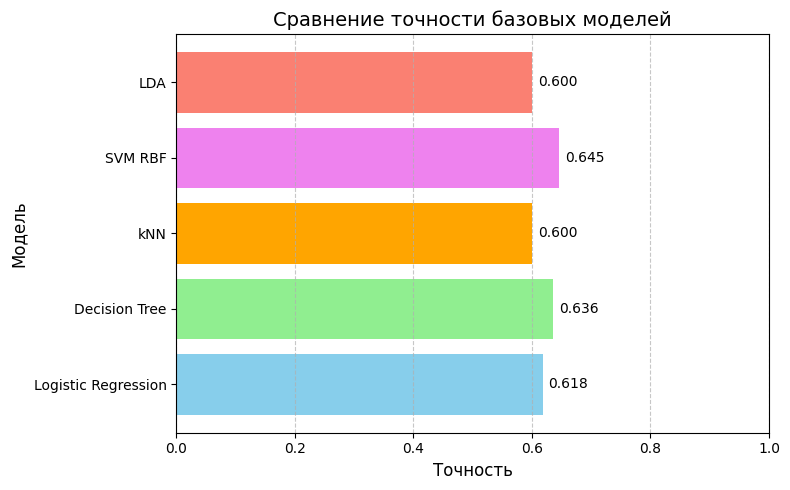

0.62


In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(list(results.keys()), list(results.values()),
         color=['skyblue', 'lightgreen', 'orange', 'violet', 'salmon'])
plt.title('Сравнение точности базовых моделей', fontsize=14)
plt.xlabel('Точность', fontsize=12)
plt.ylabel('Модель', fontsize=12)

plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, (model, acc) in enumerate(results.items()):
    plt.text(acc + 0.01, i, f"{acc:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(pd.Series(results.values()).mean())

# 2. АНСАМБЛЕВЫЕ МОДЕЛИ

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Случайный лес
print("Случайный лес")
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

results['Random Forest'] = accuracy_rf
print(f"Точность: {accuracy_rf:.4f}")

# Бэггинг на kNN
print("\nБэггинг на kNN")
bagging_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(),
    n_estimators=10,
    random_state=42
)
bagging_knn.fit(X_train_scaled, y_train)

y_pred_bag_knn = bagging_knn.predict(X_test_scaled)
accuracy_bag_knn = accuracy_score(y_test, y_pred_bag_knn)

results['Bagging kNN'] = accuracy_bag_knn
print(f"Точность: {accuracy_bag_knn:.4f}")

# AdaBoost
print("\nAdaBoost")
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
adaboost.fit(X_train, y_train)

y_pred_adaboost = adaboost.predict(X_test)
accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)

results['AdaBoost'] = accuracy_adaboost
print(f"Точность: {accuracy_adaboost:.4f}")

# Стекинг
print("\nСтекинг")
estimators = [
    ('dt', dt),
    ('svm', svm),
    ('knn', knn),
    ('lda', lda)
]
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42)
)
stacking.fit(X_train_scaled, y_train)

y_pred_stack = stacking.predict(X_test_scaled)
accuracy_stack = accuracy_score(y_test, y_pred_stack)

results['Stacking'] = accuracy_stack
print(f"Точность: {accuracy_stack:.4f}")

print("\nVOTING CLASSIFIER")
voting_clf = VotingClassifier(
    estimators=[
        ('rf', dt),
        ('gb', knn),
        ('lr', lr),
        ('lda', lda)
    ],
    voting='soft' #проверил soft и hard, у soft лучше точность
)
voting_clf.fit(X_train_scaled, y_train)

y_pred_voting_classifier = voting_clf.predict(X_test_scaled)
accuracy_voting = accuracy_score(y_test, y_pred_voting_classifier)

results['Voting Classifier'] = accuracy_voting
print(f"Точность: {accuracy_voting:.4f}")


Случайный лес
Точность: 0.6364

Бэггинг на kNN
Точность: 0.6364

AdaBoost
Точность: 0.6818

Стекинг
Точность: 0.6364

VOTING CLASSIFIER
Точность: 0.6273


/tmp/ipython-input-3362860790.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("viridis", len(ensemble_models))(range(len(ensemble_models)))


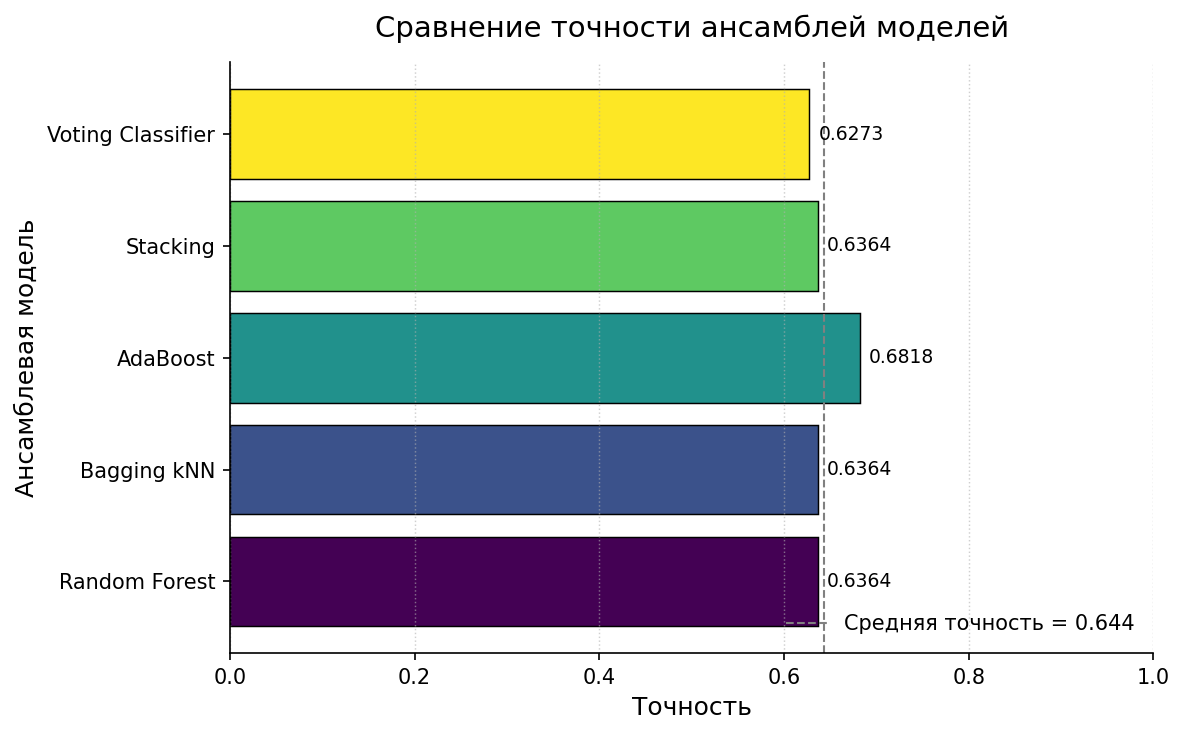

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

ensemble_models = [
    "Random Forest",
    "Bagging kNN",
    "AdaBoost",
    "Stacking",
    "Voting Classifier"
]

accuracies = np.array([results[m] for m in ensemble_models])

colors = cm.get_cmap("viridis", len(ensemble_models))(range(len(ensemble_models)))

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

bars = ax.barh(ensemble_models, accuracies,
               color=colors, edgecolor='black', linewidth=0.7)

ax.set_ylabel("Ансамблевая модель", fontsize=12)
ax.set_xlabel("Точность", fontsize=12)
ax.set_title("Сравнение точности ансамблей моделей", fontsize=14, pad=12)

mean_acc = accuracies.mean()
ax.axvline(mean_acc, color='gray', linestyle='--', linewidth=1,
           label=f"Средняя точность = {mean_acc:.3f}")

for bar, acc in zip(bars, accuracies):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
            f"{acc:.4f}",
            va='center', ha='left', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.6)
ax.set_xlim(0, 1.0)

ax.legend(frameon=False, fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()


# 3. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

In [ ]:
# Важность признаков для дерева решений
feature_importance_dt = dt.feature_importances_
feature_names = X.columns if hasattr(X, 'columns') else [f'Feature_{i}' for i in range(X.shape[1])]

# Топ-5 признаков для дерева решений
dt_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance_dt
}).sort_values('importance', ascending=False)

print("Топ-5 важных признаков (Дерево решений):")
print(dt_importance_df.head(5))

# Важность признаков для случайного леса
feature_importance_rf = rf.feature_importances_
rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance_rf
}).sort_values('importance', ascending=False)

print("\nТоп-5 важных признаков (Случайный лес):")
print(rf_importance_df.head(5))

# Сравнение топ-5 признаков
dt_top5 = set(dt_importance_df.head(5)['feature'])
rf_top5 = set(rf_importance_df.head(5)['feature'])
common_features = dt_top5.intersection(rf_top5)

print(f"\nОбщие важные признаки: {common_features}")


Топ-5 важных признаков (Дерево решений):
                  feature  importance
2       Число РХ процедур    0.220046
6                 Возраст    0.175676
1            Объем очагов    0.167594
7  Время метастазирования    0.109858
8      Время реагирования    0.099061

Топ-5 важных признаков (Случайный лес):
                  feature  importance
2       Число РХ процедур    0.192846
1            Объем очагов    0.138180
8      Время реагирования    0.122736
6                 Возраст    0.114895
7  Время метастазирования    0.103672

Общие важные признаки: {'Возраст', 'Число РХ процедур', 'Время реагирования', 'Время метастазирования', 'Объем очагов'}


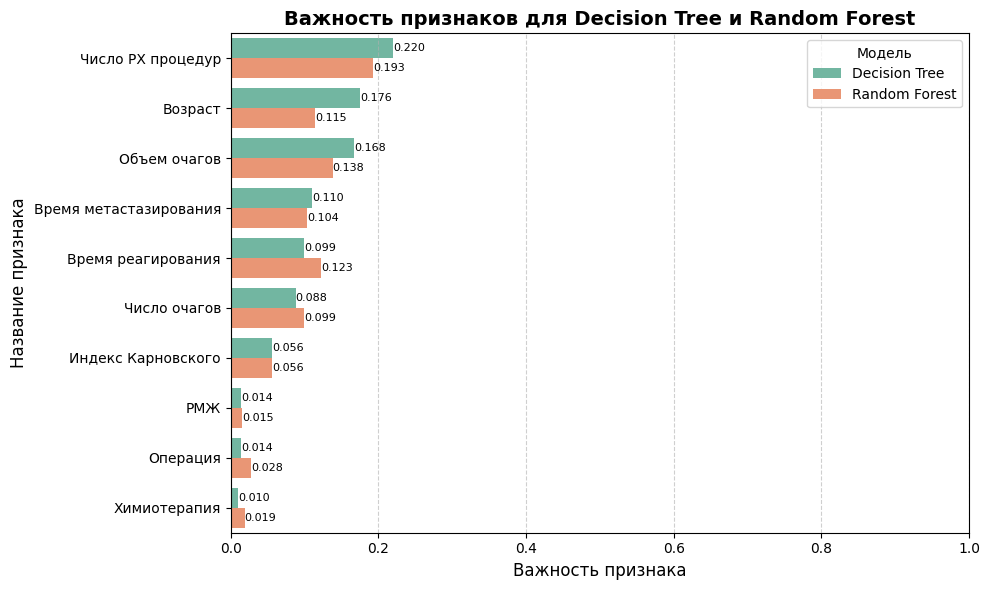

In [ ]:
dt_importance_df['model'] = 'Decision Tree'
rf_importance_df['model'] = 'Random Forest'

importance_combined = pd.concat([dt_importance_df, rf_importance_df])

top_features = (
    importance_combined.groupby('feature')['importance']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

importance_plot = importance_combined[importance_combined['feature'].isin(top_features)]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_plot,
    x='importance',
    y='feature',
    hue='model',
    palette='Set2'
)

plt.title('Важность признаков для Decision Tree и Random Forest', fontsize=14, weight='bold')
plt.xlabel('Важность признака', fontsize=12)
plt.ylabel('Название признака', fontsize=12)
plt.xlim(0, 1)
plt.legend(title='Модель', loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.3f', label_type='edge', fontsize=8)

plt.show()


# 4. СРАВНИТЕЛЬНЫЙ АНАЛИЗ

In [ ]:
# Создание таблицы результатов
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values())
}).sort_values('Accuracy', ascending=False)

print("\nСравнительная таблица точности:")
print(results_df)

# Анализ улучшения ансамблевых методов
baseline_models = ['Logistic Regression', 'Decision Tree', 'kNN', 'SVM RBF']
ensemble_models = ['Random Forest', 'Bagging kNN', 'AdaBoost', 'Stacking']

baseline_accuracy = np.mean([results[model] for model in baseline_models])
ensemble_accuracy = np.mean([results[model] for model in ensemble_models])

print(f"\nСредняя точность базовых моделей: {baseline_accuracy:.4f}")
print(f"Средняя точность ансамблевых моделей: {ensemble_accuracy:.4f}")
print(f"Улучшение: {ensemble_accuracy - baseline_accuracy:.4f}")

# Дополнительный анализ лучшей модели
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']
print(f"\nЛучшая модель: {best_model_name} с точностью {best_accuracy:.4f}")

# Детальный отчет для лучшей модели
print(f"\nДетальный отчет для {best_model_name}:")
if best_model_name in ['Logistic Regression', 'kNN', 'SVM RBF', 'Bagging kNN', 'Stacking']:
    best_model_pred = eval(f"y_pred_{best_model_name.lower().replace(' ', '_')}")
else:
    best_model_pred = eval(f"y_pred_{best_model_name.lower().replace(' ', '_')}")

print(classification_report(y_test, best_model_pred))


Сравнительная таблица точности:
                 Model  Accuracy
7             AdaBoost  0.681818
3              SVM RBF  0.645455
8             Stacking  0.636364
1        Decision Tree  0.636364
6          Bagging kNN  0.636364
5        Random Forest  0.636364
9    Voting Classifier  0.627273
0  Logistic Regression  0.618182
4                  LDA  0.600000
2                  kNN  0.600000

Средняя точность базовых моделей: 0.6250
Средняя точность ансамблевых моделей: 0.6477
Улучшение: 0.0227

Лучшая модель: AdaBoost с точностью 0.6818

Детальный отчет для AdaBoost:
              precision    recall  f1-score   support

           0       0.52      0.47      0.49        36
           1       0.75      0.78      0.77        74

    accuracy                           0.68       110
   macro avg       0.63      0.63      0.63       110
weighted avg       0.68      0.68      0.68       110



/tmp/ipython-input-2162081537.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(models_ordered))


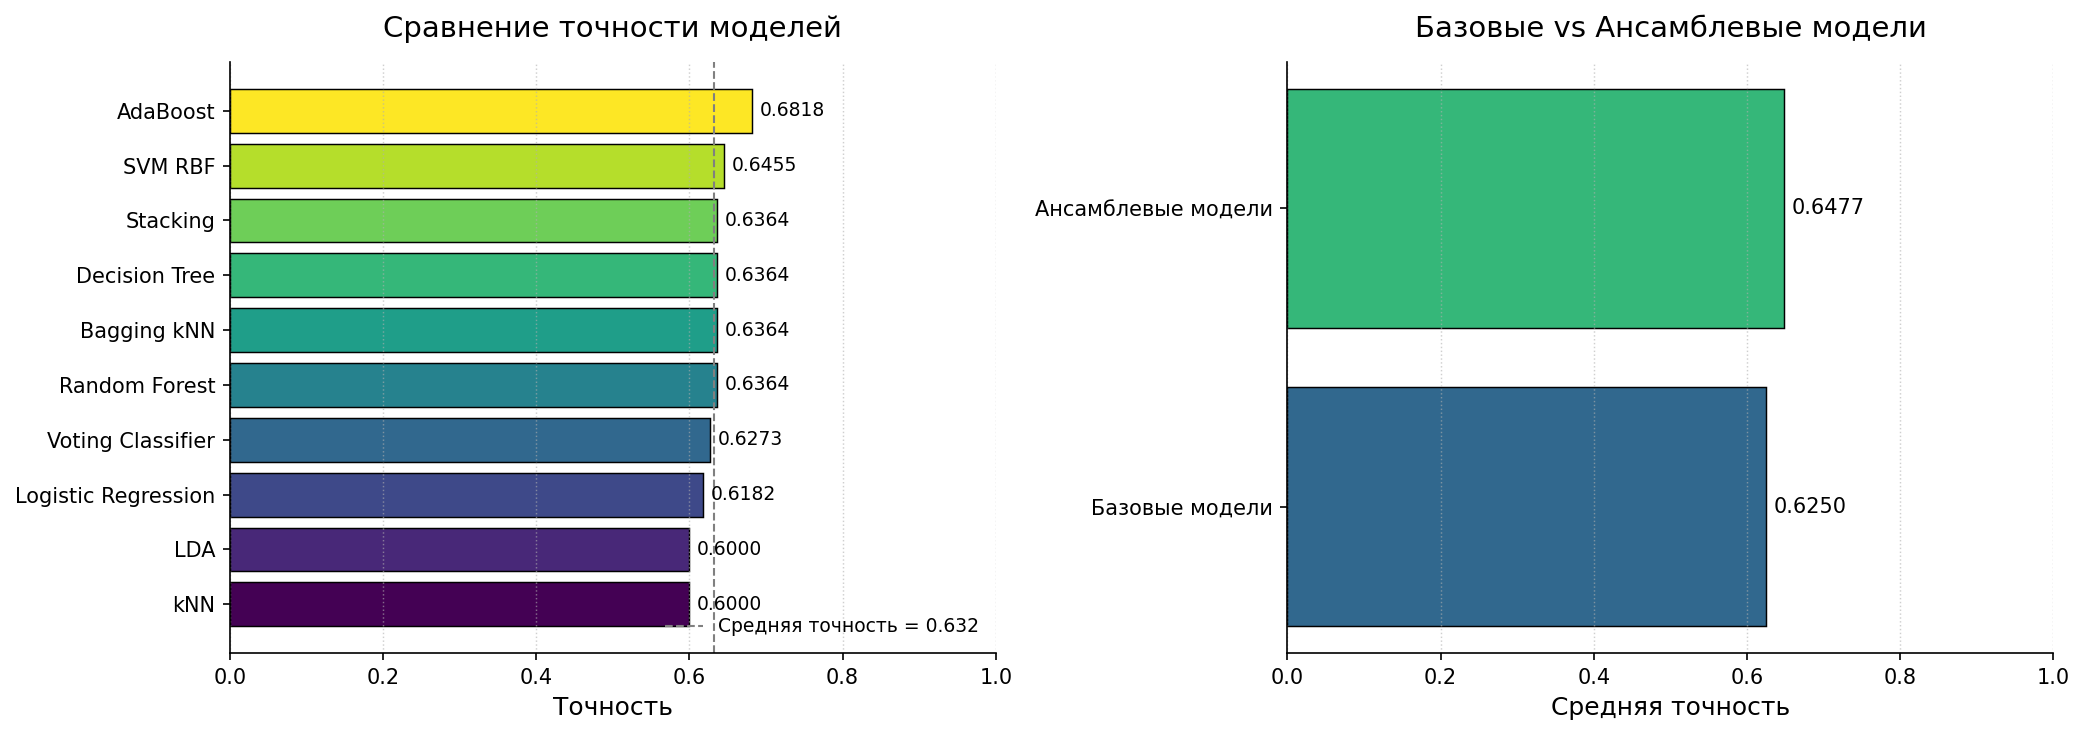

In [ ]:
import matplotlib.cm as cm
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

ax = axes[0]

results_df_sorted = results_df.sort_values('Accuracy', ascending=True)
models_ordered = results_df_sorted['Model']
accuracies_ordered = results_df_sorted['Accuracy']

cmap = cm.get_cmap("viridis", len(models_ordered))
colors = cmap(np.arange(len(models_ordered)))

bars = ax.barh(models_ordered, accuracies_ordered,
               color=colors, edgecolor='black', linewidth=0.7)

ax.set_xlabel("Точность", fontsize=12)
ax.set_title("Сравнение точности моделей", fontsize=14, pad=12)
ax.set_xlim(0, 1.0)

mean_acc = accuracies_ordered.mean()
ax.axvline(mean_acc, color='gray', linestyle='--', linewidth=1,
           label=f"Средняя точность = {mean_acc:.3f}")

for bar, acc in zip(bars, accuracies_ordered):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
            f"{acc:.4f}", va='center', ha='left', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.6)
ax.legend(frameon=False, fontsize=9, loc='lower right')


ax2 = axes[1]

avg_models = ["Базовые модели", "Ансамблевые модели"]
avg_values = [baseline_accuracy, ensemble_accuracy]

colors2 = [cmap(1/3), cmap(2/3)]

bars2 = ax2.barh(avg_models, avg_values,
                 color=colors2, edgecolor='black', linewidth=0.7)

ax2.set_xlabel("Средняя точность", fontsize=12)
ax2.set_title("Базовые vs Ансамблевые модели", fontsize=14, pad=12)
ax2.set_xlim(0, 1.0)

for bar, acc in zip(bars2, avg_values):
    ax2.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
             f"{acc:.4f}", va='center', ha='left', fontsize=10)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='x', linestyle=':', linewidth=0.7, alpha=0.6)

plt.tight_layout()
plt.show()




In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 1. CatBoost
cat = CatBoostClassifier(verbose=0, random_state=42)
cat.fit(X_train_scaled, y_train)
print("CatBoost ROC-AUC:", roc_auc_score(y_test, cat.predict_proba(X_test)[:, 1]))

# 2. LightGBM
# lgbm = LGBMClassifier(random_state=42)
# lgbm.fit(X_train_scaled, y_train)
# print("LightGBM ROC-AUC:", roc_auc_score(y_test, lgbm.predict_proba(X_test)[:, 1]))

# # 3. XGBoost
# xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
# xgb.fit(X_train_scaled, y_train)
# print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))


CatBoost ROC-AUC: 0.7218468468468469


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Инициализация моделей с фиксированными гиперпараметрами для честного сравнения
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=100, verbose=0, random_state=42)
}

# Настройка стратифицированной 5-кратной кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Метрики для оценки
scoring = {"accuracy": "accuracy", "roc_auc": "roc_auc", "f1": "f1"}

# Проход по всем моделям и кросс-валидация
results = {}
for name, model in models.items():
    cv_scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    # Вычисляем средние значения метрик по 5 фолдам
    results[name] = {
        "Accuracy": cv_scores['test_accuracy'].mean(),
        "ROC AUC": cv_scores['test_roc_auc'].mean(),
        "F1-score": cv_scores['test_f1'].mean()
    }
    print(f"{name}: "
          f"accuracy={results[name]['Accuracy']:.3f}, "
          f"ROC AUC={results[name]['ROC AUC']:.3f}, "
          f"F1={results[name]['F1-score']:.3f}")


Random Forest: accuracy=0.723, ROC AUC=0.786, F1=0.804
AdaBoost: accuracy=0.679, ROC AUC=0.773, F1=0.763
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 295, number of negative: 143
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 438, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.673516 -> initscore=0.724131
[LightGBM] [Info] Start training from score 0.724131
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wi